# Music Emotion Recognition — DEAM Dataset + Mel Spectrogram + CNN / CRNN-GRU

Pipeline ini mengikuti **music-and-neuro-engineering.ipynb** secara penuh:
- Dataset audio: **DEAM** (~1800 lagu MP3)
- Label: anotasi valence & arousal dari DEAM CSV → 4 kuadran Russell
- Threshold: KDE Valley Detection (data-driven, bukan hardcoded 5.0)
- Fitur: **Mel Spectrogram** (bukan YAMNet)
- Arsitektur: **CNN** dan **CRNN-GRU**

## 1. Import Library

In [27]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, Model
from tensorflow.keras.utils import to_categorical

import random
import joblib
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     for gpu in gpus:
#         tf.config.experimental.set_memory_growth(gpu, True)
#     print(f"GPU terdeteksi: {len(gpus)}")
# else:
#     print("Tidak ada GPU — training menggunakan CPU")

# print(f"TensorFlow: {tf.__version__}")
# print("Semua library berhasil diimpor!")

GPU terdeteksi: 1
TensorFlow: 2.19.0
Semua library berhasil diimpor!


In [28]:
# Mencari nama folder dataset pertama yang ada di /kaggle/input/
input_folders = os.listdir('/kaggle/input')
if input_folders:
    BASE_DIR = os.path.join('/kaggle/input', input_folders[0])
    print(f"BASE_DIR otomatis: {BASE_DIR}")

BASE_DIR otomatis: /kaggle/input/datasets


## 2. Konfigurasi Path Dataset DEAM

Sesuaikan path di bawah ini dengan lokasi dataset kamu.

In [29]:
# ============================================================
# Sesuaikan path ini
# ============================================================

# Lokal (Windows):
# BASE_DIR  = r"D:\tugas\skripsi\Deam_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

# Kaggle (uncomment jika perlu):
BASE_DIR = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                             "annotations averaged per song", "song_level")

# Google Colab (uncomment jika perlu):
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_DIR  = "/content/drive/MyDrive/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

ANNOT_FILE_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
ANNOT_FILE_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# File cache untuk menyimpan hasil ekstraksi
CACHE_FILE = "deam_mel_features.pkl"

print(f"Audio dir  : {AUDIO_DIR}")
print(f"Annot file 1: {ANNOT_FILE_1}")
print(f"Annot file 2: {ANNOT_FILE_2}")
print(f"Cache file  : {CACHE_FILE}")

Audio dir  : /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio
Annot file 1: /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv
Annot file 2: /kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv
Cache file  : deam_mel_features.pkl


## 3. Load & Gabungkan Anotasi DEAM

In [30]:
df1 = pd.read_csv(ANNOT_FILE_1)
df2 = pd.read_csv(ANNOT_FILE_2)

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(f"File 1: {df1.shape} | Kolom: {list(df1.columns)}")
print(f"File 2: {df2.shape} | Kolom: {list(df2.columns)}")

# Pilih kolom yang ada di kedua file
common_cols = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
annotations = pd.concat(
    [df1[common_cols], df2[common_cols]], ignore_index=True
).drop_duplicates(subset='song_id').reset_index(drop=True)

print(f"\nTotal anotasi gabungan: {len(annotations)}")
print(f"Missing values:\n{annotations.isnull().sum()}")
annotations[['valence_mean', 'arousal_mean']].describe()

File 1: (1744, 5) | Kolom: ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
File 2: (58, 13) | Kolom: ['song_id', 'valence_mean', 'valence_std', 'valence_ max_mean', 'valence_max_std', 'valence_min_mean', 'valence_min_std', 'arousal_mean', 'arousal_std', 'arousal_max_mean', 'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']

Total anotasi gabungan: 1802
Missing values:
song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
dtype: int64


,valence_mean,arousal_mean
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


## 4. Filter Lagu yang Memiliki File Audio

Total file audio: 1802
Lagu dengan audio: 1802
Lagu tanpa audio : 0

Dataset final: 1802 lagu


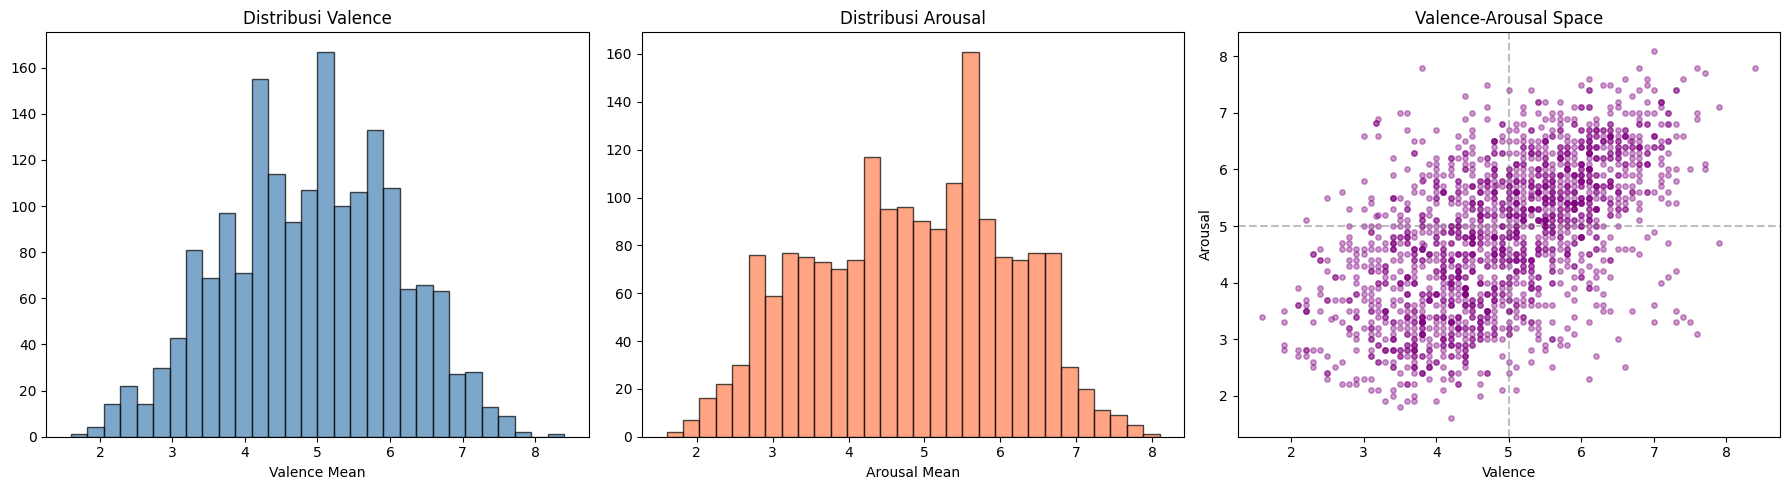

In [31]:
available_audio = set()
for fname in os.listdir(AUDIO_DIR):
    if fname.endswith('.mp3'):
        try:
            song_id = int(os.path.splitext(fname)[0])
            available_audio.add(song_id)
        except:
            pass

annotations['has_audio'] = annotations['song_id'].isin(available_audio)
print(f"Total file audio: {len(available_audio)}")
print(f"Lagu dengan audio: {annotations['has_audio'].sum()}")
print(f"Lagu tanpa audio : {(~annotations['has_audio']).sum()}")

annotations = annotations[annotations['has_audio']].drop(columns='has_audio').reset_index(drop=True)
print(f"\nDataset final: {len(annotations)} lagu")

# Plot distribusi valence-arousal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(annotations['valence_mean'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Valence')
axes[0].set_xlabel('Valence Mean')

axes[1].hist(annotations['arousal_mean'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Arousal')
axes[1].set_xlabel('Arousal Mean')

axes[2].scatter(annotations['valence_mean'], annotations['arousal_mean'],
                alpha=0.4, s=15, c='purple')
axes[2].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Valence-Arousal Space')
axes[2].set_xlabel('Valence')
axes[2].set_ylabel('Arousal')

plt.tight_layout()
plt.show()

## 5. KDE Valley Detection — Threshold Data-Driven

Mengikuti pipeline referensi: threshold valence & arousal ditentukan otomatis dari lembah distribusi data.

Mencari threshold data-driven via KDE valley detection...
  Distribusi unimodal — menggunakan median = 4.900
  Distribusi unimodal — menggunakan median = 4.900
  Valence threshold (valley): 4.900  (hardcoded: 5.0)
  Arousal threshold (valley): 4.900  (hardcoded: 5.0)


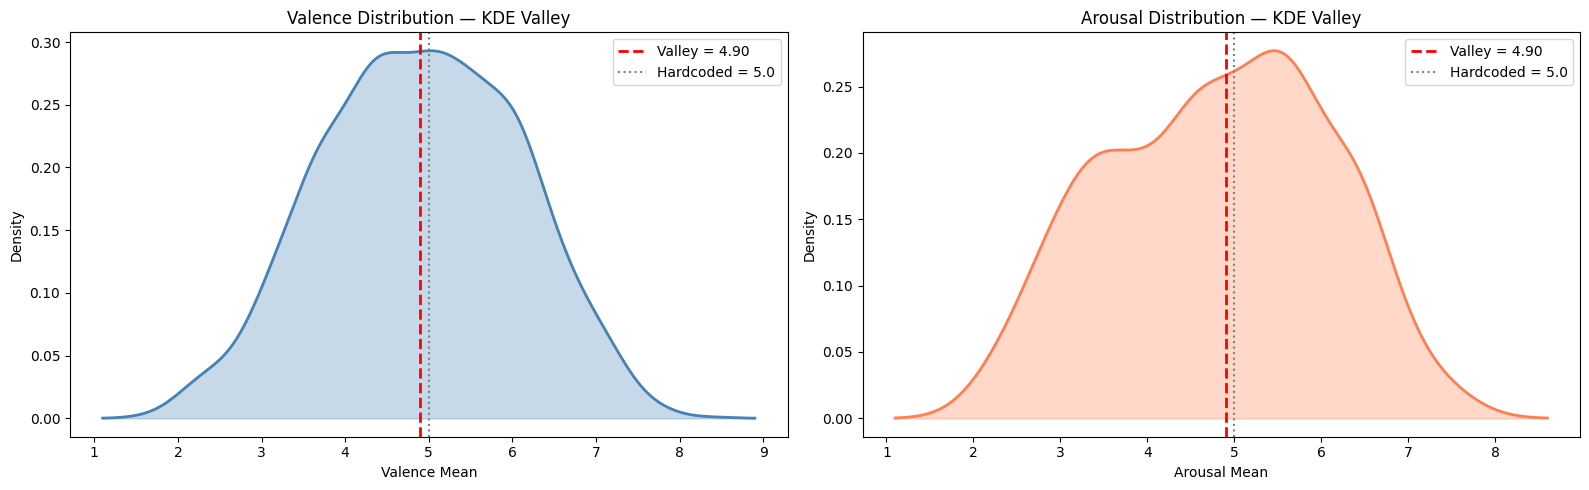

In [32]:
def find_kde_valley(values, grid_points=1000):
    """
    Temukan lembah (local minimum) dari KDE distribusi nilai 1D.
    Lembah = titik pemisah alami distribusi bimodal.
    Jika tidak ada lembah, gunakan median.
    """
    kde = gaussian_kde(values, bw_method='scott')
    x_grid = np.linspace(values.min() - 0.5, values.max() + 0.5, grid_points)
    kde_y = kde(x_grid)

    local_min_idx = argrelextrema(kde_y, np.less, order=20)[0]

    if len(local_min_idx) > 0:
        center = np.median(values)
        dists  = np.abs(x_grid[local_min_idx] - center)
        best   = local_min_idx[np.argmin(dists)]
        valley = float(x_grid[best])
    else:
        valley = float(np.median(values))
        print(f"  Distribusi unimodal — menggunakan median = {valley:.3f}")

    return valley, x_grid, kde_y


print("Mencari threshold data-driven via KDE valley detection...")
VALENCE_THRESHOLD, val_x, val_kde = find_kde_valley(annotations['valence_mean'].values)
AROUSAL_THRESHOLD, aro_x, aro_kde = find_kde_valley(annotations['arousal_mean'].values)

print(f"  Valence threshold (valley): {VALENCE_THRESHOLD:.3f}  (hardcoded: 5.0)")
print(f"  Arousal threshold (valley): {AROUSAL_THRESHOLD:.3f}  (hardcoded: 5.0)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, x, kde_y, threshold, label, color in [
    (axes[0], val_x, val_kde, VALENCE_THRESHOLD, 'Valence', 'steelblue'),
    (axes[1], aro_x, aro_kde, AROUSAL_THRESHOLD, 'Arousal', 'coral'),
]:
    ax.fill_between(x, kde_y, alpha=0.3, color=color)
    ax.plot(x, kde_y, color=color, lw=2)
    ax.axvline(x=threshold, color='red', linestyle='--', lw=2,
               label=f'Valley = {threshold:.2f}')
    ax.axvline(x=5.0, color='gray', linestyle=':', lw=1.5,
               label='Hardcoded = 5.0')
    ax.set_title(f'{label} Distribution — KDE Valley')
    ax.set_xlabel(f'{label} Mean')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Pemetaan Emosi → 4 Kuadran Russell

Distribusi kelas emosi:
emotion
Happy/Excited    679
Sad/Depressed    638
Calm/Relaxed     251
Angry/Tense      234
Name: count, dtype: int64

Total sampel: 1802


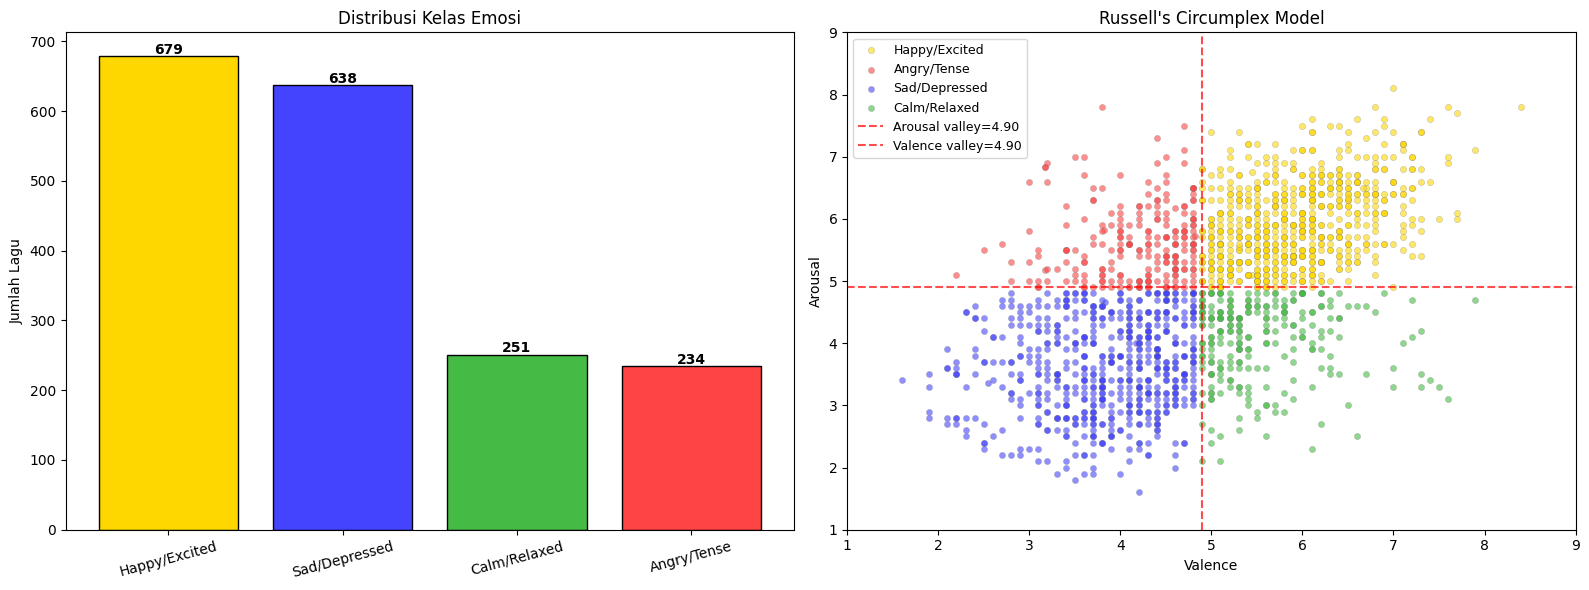

In [33]:
def map_emotion(valence, arousal,
                val_thr=VALENCE_THRESHOLD, aro_thr=AROUSAL_THRESHOLD):
    """
    Petakan valence & arousal ke 4 kuadran Russell Circumplex Model.
    Menggunakan threshold data-driven dari KDE valley.
    """
    if valence >= val_thr and arousal >= aro_thr:
        return 'Happy/Excited'   # HVHA
    elif valence < val_thr and arousal >= aro_thr:
        return 'Angry/Tense'    # LVHA
    elif valence < val_thr and arousal < aro_thr:
        return 'Sad/Depressed'  # LVLA
    else:
        return 'Calm/Relaxed'   # HVLA


annotations['emotion'] = annotations.apply(
    lambda row: map_emotion(row['valence_mean'], row['arousal_mean']), axis=1
)

print("Distribusi kelas emosi:")
print(annotations['emotion'].value_counts())
print(f"\nTotal sampel: {len(annotations)}")

# Visualisasi
colors = {
    'Happy/Excited':  '#FFD700',
    'Angry/Tense':    '#FF4444',
    'Sad/Depressed':  '#4444FF',
    'Calm/Relaxed':   '#44BB44',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
emotion_counts = annotations['emotion'].value_counts()
bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=[colors[e] for e in emotion_counts.index], edgecolor='black')
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_ylabel('Jumlah Lagu')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold')

# Scatter plot
for emotion, color in colors.items():
    subset = annotations[annotations['emotion'] == emotion]
    axes[1].scatter(subset['valence_mean'], subset['arousal_mean'],
                    c=color, label=emotion, alpha=0.6, s=20, edgecolors='gray', lw=0.3)
axes[1].axhline(y=AROUSAL_THRESHOLD, color='red', linestyle='--', alpha=0.7,
                label=f'Arousal valley={AROUSAL_THRESHOLD:.2f}')
axes[1].axvline(x=VALENCE_THRESHOLD, color='red', linestyle='--', alpha=0.7,
                label=f'Valence valley={VALENCE_THRESHOLD:.2f}')
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Arousal')
axes[1].set_title("Russell's Circumplex Model")
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, 9)
axes[1].set_ylim(1, 9)

plt.tight_layout()
plt.show()

## 7. Ekstraksi Mel Spectrogram

Jika cache file sudah ada, langsung load. Jika belum, ekstraksi dari audio.

In [34]:
# ============================================================
# Konfigurasi ekstraksi
# ============================================================
SR         = 22050
DURATION   = 45.0      # detik (sesuai DEAM)
N_FFT      = 2048
HOP_LENGTH = 512
N_MELS     = 128
MIN_DB     = -80.0
TARGET_FREQ = 128
TARGET_TIME = 128


def extract_mel(filepath, sr=SR, duration=DURATION,
                n_fft=N_FFT, hop_length=HOP_LENGTH,
                n_mels=N_MELS, min_db=MIN_DB):
    """
    Load audio dan ekstraksi log-Mel spectrogram.
    Return array (n_mels, time_frames) ternormalisasi ke [0, 1].
    """
    y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_clipped = np.clip(mel_db, min_db, 0.0).astype(np.float32)
    mel_norm = (mel_clipped - min_db) / abs(min_db)
    return mel_norm  # (N_MELS, time_frames)


def resize_mel(mel_norm, target_freq=TARGET_FREQ, target_time=TARGET_TIME):
    """Resize mel spectrogram ke dimensi target."""
    resized = tf.image.resize(
        mel_norm[..., np.newaxis],
        [target_freq, target_time],
        method='bilinear'
    ).numpy().squeeze(-1)
    return np.clip(resized, 0.0, 1.0).astype(np.float32)


# ============================================================
# Load cache atau ekstraksi ulang
# ============================================================
if os.path.exists(CACHE_FILE):
    print(f"Cache ditemukan! Memuat dari {CACHE_FILE}...")
    mel_data = joblib.load(CACHE_FILE)
    print(f"Berhasil memuat {len(mel_data)} lagu dari cache.")
else:
    mel_data = {}  # song_id (int) → mel array
    failed   = []

    print(f"Mengekstraksi Mel Spectrogram untuk {len(annotations)} lagu...")
    for _, row in tqdm(annotations.iterrows(), total=len(annotations)):
        song_id   = int(row['song_id'])
        audio_path = os.path.join(AUDIO_DIR, f"{song_id}.mp3")
        try:
            mel = extract_mel(audio_path)
            mel_data[song_id] = resize_mel(mel)
        except Exception as e:
            failed.append(song_id)

    print(f"Berhasil: {len(mel_data)} | Gagal: {len(failed)}")
    if failed:
        print(f"Song ID gagal: {failed[:10]}{'...' if len(failed) > 10 else ''}")

    # Simpan cache
    print(f"Menyimpan cache ke {CACHE_FILE}...")
    joblib.dump(mel_data, CACHE_FILE)
    print("Cache berhasil disimpan!")

# Filter anotasi agar hanya lagu yang berhasil diekstraksi
annotations = annotations[
    annotations['song_id'].isin(mel_data.keys())
].reset_index(drop=True)

print(f"\nDataset final setelah filter: {len(annotations)} lagu")

# Verifikasi shape
sample = mel_data[next(iter(mel_data))]
print(f"Shape mel spectrogram: {sample.shape}")

Mengekstraksi Mel Spectrogram untuk 1802 lagu...


100%|██████████| 1802/1802 [06:19<00:00,  4.75it/s]


Berhasil: 1802 | Gagal: 0
Menyimpan cache ke deam_mel_features.pkl...
Cache berhasil disimpan!

Dataset final setelah filter: 1802 lagu
Shape mel spectrogram: (128, 128)


## 8. Visualisasi Mel Spectrogram per Kuadran Emosi

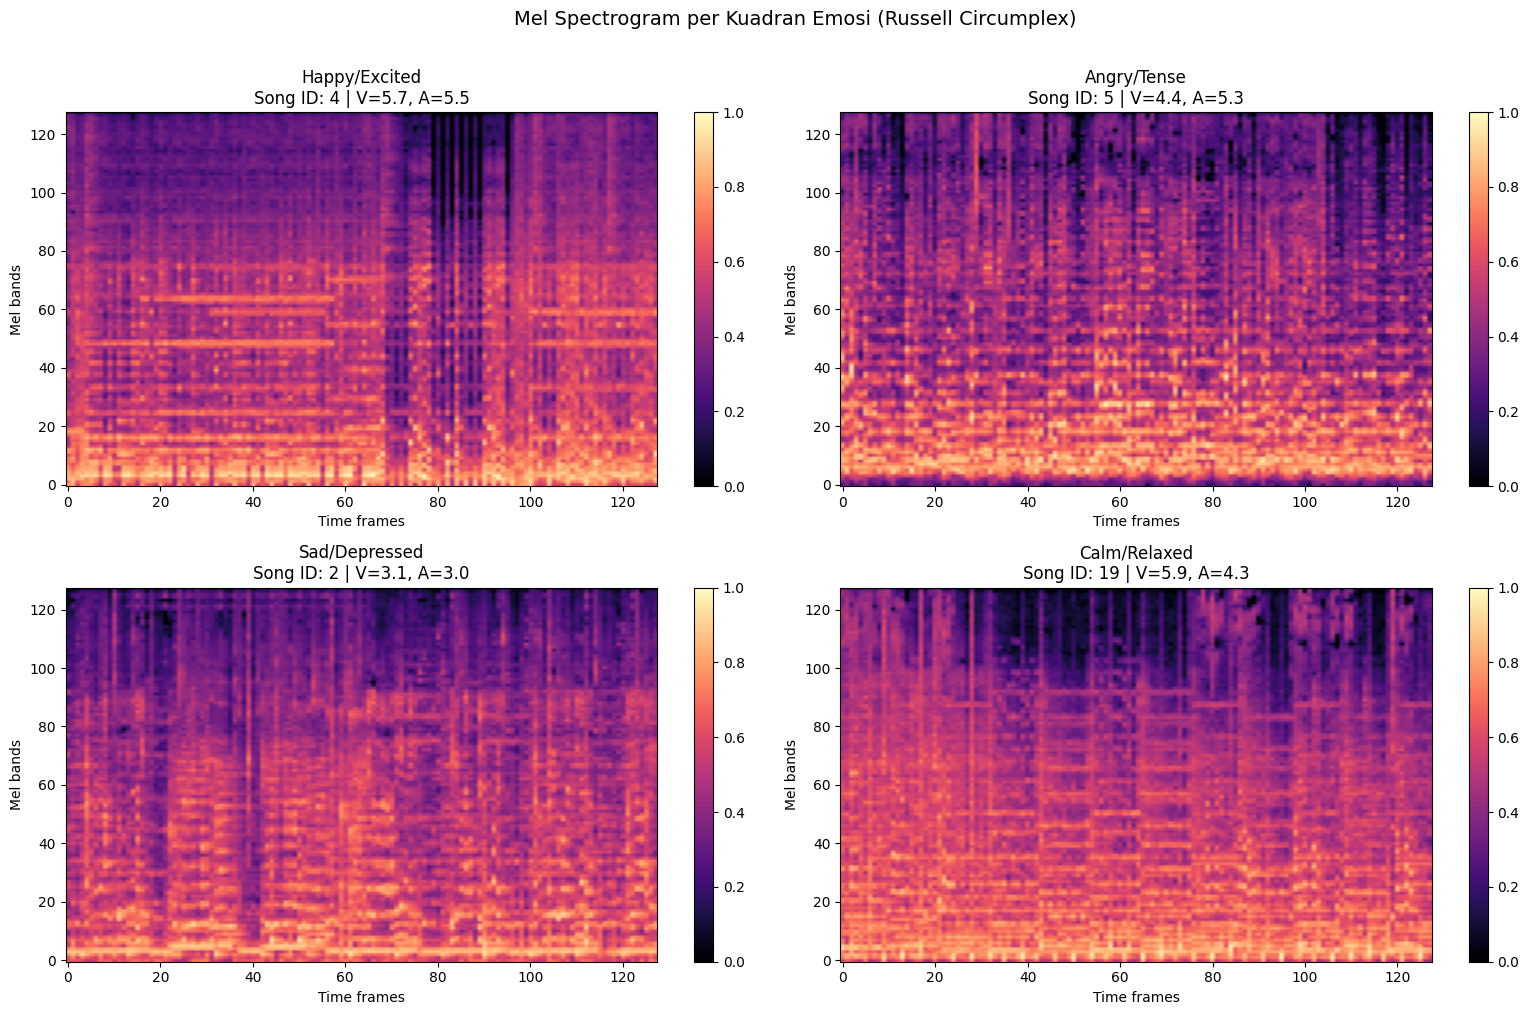

In [35]:
quadrant_colors = {
    'Happy/Excited':  '#FFD700',
    'Angry/Tense':    '#FF4444',
    'Sad/Depressed':  '#4444FF',
    'Calm/Relaxed':   '#44BB44',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (quadrant, color) in enumerate(quadrant_colors.items()):
    sample_row = annotations[annotations['emotion'] == quadrant].iloc[0]
    song_id    = int(sample_row['song_id'])
    mel        = mel_data[song_id]

    im = axes[i].imshow(
        mel, aspect='auto', origin='lower',
        cmap='magma', vmin=0, vmax=1
    )
    axes[i].set_title(
        f"{quadrant}\nSong ID: {song_id} | "
        f"V={sample_row['valence_mean']:.1f}, A={sample_row['arousal_mean']:.1f}",
        fontsize=12
    )
    axes[i].set_xlabel('Time frames')
    axes[i].set_ylabel('Mel bands')
    plt.colorbar(im, ax=axes[i])

plt.suptitle('Mel Spectrogram per Kuadran Emosi (Russell Circumplex)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Label Encoding & Train/Val/Test Split

In [36]:
le = LabelEncoder()
annotations['label'] = le.fit_transform(annotations['emotion'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Kelas emosi  : {CLASS_NAMES}")
print(f"Jumlah kelas : {NUM_CLASSES}")

song_ids = annotations['song_id'].values
labels   = annotations['label'].values

# Split 70/15/15 stratified by label
ids_tv, ids_test, y_tv, y_test = train_test_split(
    song_ids, labels, test_size=0.15, random_state=SEED, stratify=labels
)
ids_train, ids_val, y_train, y_val = train_test_split(
    ids_tv, y_tv, test_size=0.176, random_state=SEED, stratify=y_tv
)

print(f"\nJumlah split — Train: {len(ids_train)}, Val: {len(ids_val)}, Test: {len(ids_test)}")

print("\nDistribusi kelas per split:")
for idx, cls in enumerate(CLASS_NAMES):
    tr = (y_train == idx).sum()
    va = (y_val   == idx).sum()
    te = (y_test  == idx).sum()
    print(f"  {cls:20s}: train={tr}, val={va}, test={te}")

# Class weights
cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw_arr)}
print(f"\nClass weights: { {CLASS_NAMES[k]: round(v, 3) for k, v in CLASS_WEIGHTS.items()} }")

Kelas emosi  : ['Angry/Tense', 'Calm/Relaxed', 'Happy/Excited', 'Sad/Depressed']
Jumlah kelas : 4

Jumlah split — Train: 1261, Val: 270, Test: 271

Distribusi kelas per split:
  Angry/Tense         : train=164, val=35, test=35
  Calm/Relaxed        : train=176, val=37, test=38
  Happy/Excited       : train=475, val=102, test=102
  Sad/Depressed       : train=446, val=96, test=96

Class weights: {'Angry/Tense': 1.922, 'Calm/Relaxed': 1.791, 'Happy/Excited': 0.664, 'Sad/Depressed': 0.707}


## 10. Augmentasi & Pembuatan Array Dataset

In [37]:
def augment_mel(mel, rng, time_mask_w=30, freq_mask_w=15, noise_std=0.015):
    """
    Augmentasi SpecAugment pada mel spectrogram (freq, time):
      - Time masking
      - Frequency masking
      - Gaussian noise
      - Time shift
    """
    mel = mel.copy()
    freq_bins, time_steps = mel.shape

    if rng.random() < 0.5:
        w = rng.integers(1, time_mask_w + 1)
        t = rng.integers(0, max(1, time_steps - w))
        mel[:, t:t + w] = 0.0

    if rng.random() < 0.5:
        w = rng.integers(1, freq_mask_w + 1)
        f = rng.integers(0, max(1, freq_bins - w))
        mel[f:f + w, :] = 0.0

    if rng.random() < 0.4:
        mel = np.clip(
            mel + rng.normal(0, noise_std, mel.shape).astype(np.float32),
            0.0, 1.0
        )

    if rng.random() < 0.4:
        shift = rng.integers(-20, 21)
        mel = np.roll(mel, shift, axis=1)

    return mel.astype(np.float32)


def build_arrays(song_ids_arr, labels_arr, augment=False, n_aug=2):
    """
    Bangun array X dan y dari song_id list.
    Jika augment=True, tiap sampel ditambah n_aug versi augmentasi.
    """
    X_list, y_list = [], []
    rng = np.random.default_rng(SEED)

    for song_id, label in zip(song_ids_arr, labels_arr):
        mel = mel_data[int(song_id)]
        X_list.append(mel)
        y_list.append(label)

        if augment:
            for _ in range(n_aug):
                X_list.append(augment_mel(mel, rng))
                y_list.append(label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


print("Membangun array dataset...")
X_train_raw, y_train_enc = build_arrays(ids_train, y_train, augment=True,  n_aug=2)
X_val_raw,   y_val_enc   = build_arrays(ids_val,   y_val,   augment=False)
X_test_raw,  y_test_enc  = build_arrays(ids_test,  y_test,  augment=False)

print(f"X_train: {X_train_raw.shape}  |  X_val: {X_val_raw.shape}  |  X_test: {X_test_raw.shape}")

print("\nDistribusi kelas training (setelah augmentasi):")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {(y_train_enc == idx).sum()}")

Membangun array dataset...
X_train: (3783, 128, 128)  |  X_val: (270, 128, 128)  |  X_test: (271, 128, 128)

Distribusi kelas training (setelah augmentasi):
  Angry/Tense: 492
  Calm/Relaxed: 528
  Happy/Excited: 1425
  Sad/Depressed: 1338


## 11. Persiapan Input per Model

- **CNN** : input `(freq, time, 1)` — 2D image
- **CRNN-GRU** : input `(time, freq)` — sekuens vektor frekuensi

In [38]:
# CNN: (N, freq, time, 1)
X_train_cnn  = X_train_raw[..., np.newaxis]
X_val_cnn    = X_val_raw[..., np.newaxis]
X_test_cnn   = X_test_raw[..., np.newaxis]

# CRNN-GRU: (N, time, freq) — transpose dimensi terakhir
X_train_crnn = np.transpose(X_train_raw, (0, 2, 1))
X_val_crnn   = np.transpose(X_val_raw,   (0, 2, 1))
X_test_crnn  = np.transpose(X_test_raw,  (0, 2, 1))

# One-hot labels
y_train_oh = to_categorical(y_train_enc, NUM_CLASSES)
y_val_oh   = to_categorical(y_val_enc,   NUM_CLASSES)
y_test_oh  = to_categorical(y_test_enc,  NUM_CLASSES)

CNN_INPUT_SHAPE  = X_train_cnn.shape[1:]   # (128, 128, 1)
CRNN_INPUT_SHAPE = X_train_crnn.shape[1:]  # (128, 128)

print(f"CNN  input shape : {CNN_INPUT_SHAPE}")
print(f"CRNN input shape : {CRNN_INPUT_SHAPE}")

CNN  input shape : (128, 128, 1)
CRNN input shape : (128, 128)


## 12. Arsitektur Model A: CNN (Residual)

SeparableConv2D + Residual Blocks + Dual Pooling (GAP + GMP).

In [39]:
def conv_bn_swish(x, filters, kernel=3, strides=1, wd=1e-4):
    x = layers.SeparableConv2D(
        filters, kernel, strides=strides, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(wd),
        pointwise_regularizer=regularizers.l2(wd)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    return x


def residual_block_2d(x, filters, pool=False, drop=0.0):
    shortcut = x
    x = conv_bn_swish(x, filters)
    x = conv_bn_swish(x, filters)
    if pool:
        x = layers.AveragePooling2D(2)(x)
        shortcut = layers.AveragePooling2D(2)(shortcut)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)
    if drop > 0:
        x = layers.SpatialDropout2D(drop)(x)
    return x


def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name='mel_input')

    x = layers.Conv2D(32, 5, strides=2, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = residual_block_2d(x, 32,  pool=False, drop=0.05)
    x = residual_block_2d(x, 64,  pool=True,  drop=0.08)
    x = residual_block_2d(x, 128, pool=True,  drop=0.10)
    x = residual_block_2d(x, 256, pool=True,  drop=0.12)

    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    feat = layers.Concatenate()([gap, gmp])

    x = layers.Dense(256, use_bias=False, kernel_regularizer=regularizers.l2(1e-4))(feat)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, use_bias=False, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax', name='emotion')(x)
    return Model(inp, out, name='CNN_Emotion')


tf.keras.backend.clear_session()
cnn_model = build_cnn(CNN_INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

Model: "CNN_Emotion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        800 │ mel_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 64, 64,    │      1,312 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 64, 64,    │      1,312 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ activation_2[0][… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 64, 64,    │      2,336 │ spatial_dropout2… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 64, 64,    │      4,672 │ activation_4[0][

 Total params: 353,156 (1.35 MB)

 Trainable params: 349,508 (1.33 MB)

 Non-trainable params: 3,648 (14.25 KB)

## 13. Arsitektur Model B: CRNN-GRU

TimeDistributed CNN mengekstraksi fitur lokal, Bidirectional GRU memproses urutan temporal.

In [40]:
def build_crnn_gru(input_shape, num_classes):
    """
    CRNN-GRU:
      Input  : (time_steps, freq_bins)
      CNN    : TimeDistributed Conv1D untuk ekstraksi fitur per time step
      GRU    : Bidirectional GRU x2 untuk temporal modeling
      Output : softmax atas num_classes
    """
    inp = layers.Input(shape=input_shape, name='crnn_input')  # (T, F)

    # Expand ke (T, F, 1) untuk Conv1D lokal
    x = layers.Reshape((input_shape[0], input_shape[1], 1))(inp)

    # --- CNN lokal per time step via TimeDistributed ---
    # Block 1
    x = layers.TimeDistributed(
        layers.Conv1D(64, 3, padding='same', use_bias=False)
    )(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.Activation('relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

    # Block 2
    x = layers.TimeDistributed(
        layers.Conv1D(128, 3, padding='same', use_bias=False)
    )(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.Activation('relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

    # Block 3
    x = layers.TimeDistributed(
        layers.Conv1D(256, 3, padding='same', use_bias=False)
    )(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.Activation('relu'))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling1D())(x)  # (T, 256)

    x = layers.Dropout(0.3)(x)

    # --- Bidirectional GRU ---
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)  # (T, 256)
    x = layers.LayerNormalization()(x)

    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.1)
    )(x)  # (128,)
    x = layers.LayerNormalization()(x)

    # --- Classifier head ---
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax', name='emotion')(x)

    return Model(inp, out, name='CRNN_GRU_Emotion')


tf.keras.backend.clear_session()
crnn_model = build_crnn_gru(CRNN_INPUT_SHAPE, NUM_CLASSES)
crnn_model.summary()

Model: "CRNN_GRU_Emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ crnn_input (InputLayer)         │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 128, 64)   │           192 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 128, 128, 64)   │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 128, 128, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 128, 64, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 128, 64, 128)   │        24,576 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 128, 64, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 128, 64, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 128, 32, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 128, 32, 256)   │        98,304 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 128, 32, 256)   │         1,024 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 128, 32, 256)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 128, 256)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 570,756 (2.18 MB)

 Trainable params: 569,860 (2.17 MB)

 Non-trainable params: 896 (3.50 KB)

## 14. Helper: Callbacks, Plot, Evaluasi

In [41]:
EPOCHS     = 80
BATCH_SIZE = 32


def get_callbacks(model_name, monitor='val_accuracy', patience_es=15, patience_lr=7):
    return [
        callbacks.EarlyStopping(
            monitor=monitor, mode='max', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor=monitor, mode='max', factor=0.5,
            patience=patience_lr, min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor=monitor, mode='max',
            save_best_only=True, verbose=0
        ),
    ]


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test_oh, y_test_enc, model_name):
    loss, acc = model.evaluate(X_test, y_test_oh, verbose=0)
    y_pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true    = y_test_enc

    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mf1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)

    print(f"\n{'='*52}")
    print(f"  Hasil Evaluasi: {model_name}")
    print(f"{'='*52}")
    print(f"  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Weighted F1   : {wf1:.4f}")
    print(f"  Macro F1      : {mf1:.4f}")
    print(f"  Test Loss     : {loss:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix (Acc: {acc*100:.2f}%)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    return acc, wf1, mf1


print("Helper functions siap.")

Helper functions siap.


## 15. Training Model A: CNN

Training CNN...
Epoch 1/80


I0000 00:00:1777101106.077528     155 service.cc:152] XLA service 0x2b0a04a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777101106.077573     155 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777101107.746894     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777101123.004924     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 296ms/step - accuracy: 0.3331 - loss: 1.6598 - val_accuracy: 0.1296 - val_loss: 1.5988 - learning_rate: 0.0010
Epoch 2/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4414 - loss: 1.4735 - val_accuracy: 0.1296 - val_loss: 1.8968 - learning_rate: 0.0010
Epoch 3/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.4608 - loss: 1.4296 - val_accuracy: 0.1296 - val_loss: 1.7204 - learning_rate: 0.0010
Epoch 4/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5083 - loss: 1.3829 - val_accuracy: 0.2556 - val_loss: 1.5752 - learning_rate: 0.0010
Epoch 5/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5108 - loss: 1.3628 - val_accuracy: 0.3259 - val_loss: 1.4233 - learning_rate: 0.0010
Epoch 6/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5122 - loss: 1.3301 - val_accuracy: 0.4889 - val_loss: 1.4426 - learning_rate: 0.0010
Epoch 7/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5246 - loss: 1.3200 - va

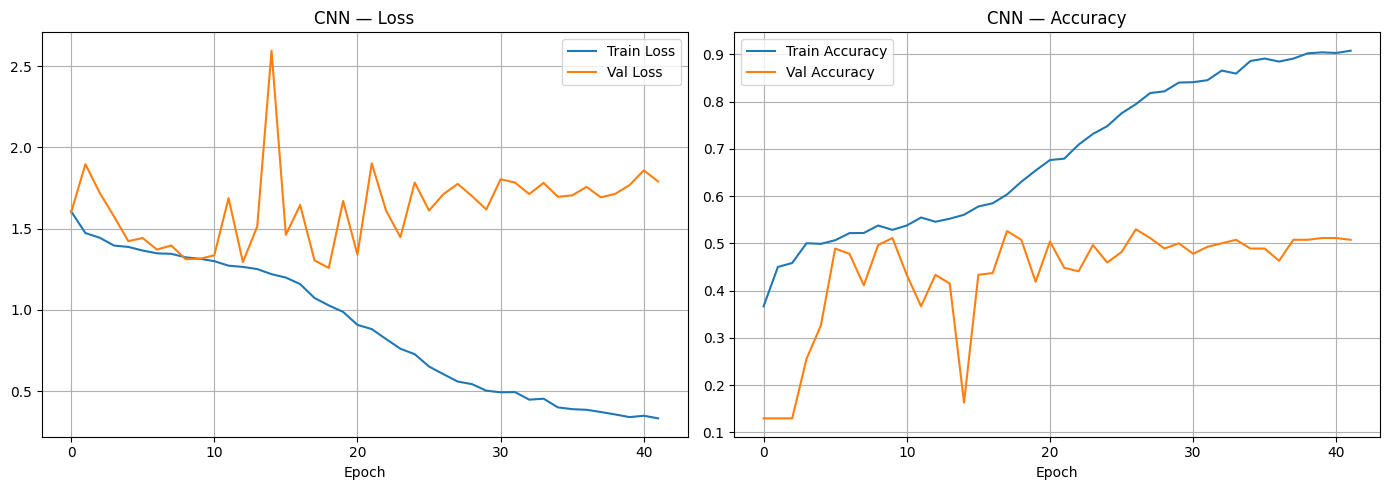

In [42]:
tf.keras.backend.clear_session()
cnn_model = build_cnn(CNN_INPUT_SHAPE, NUM_CLASSES)
cnn_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN...")
history_cnn = cnn_model.fit(
    X_train_cnn, y_train_oh,
    validation_data=(X_val_cnn, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('cnn'),
    verbose=1,
)

print(f"Best val_accuracy CNN: {max(history_cnn.history['val_accuracy']):.4f}")
plot_history(history_cnn, 'CNN')

## 16. Training Model B: CRNN-GRU

Training CRNN-GRU...
Epoch 1/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - accuracy: 0.3540 - loss: 1.4332 - val_accuracy: 0.4407 - val_loss: 1.2824 - learning_rate: 5.0000e-04
Epoch 2/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.4466 - loss: 1.3123 - val_accuracy: 0.4444 - val_loss: 1.3001 - learning_rate: 5.0000e-04
Epoch 3/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.4981 - loss: 1.2801 - val_accuracy: 0.5593 - val_loss: 1.2410 - learning_rate: 5.0000e-04
Epoch 4/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.4999 - loss: 1.2633 - val_accuracy: 0.5704 - val_loss: 1.2517 - learning_rate: 5.0000e-04
Epoch 5/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.5011 - loss: 1.2631 - val_accuracy: 0.5593 - val_loss: 1.2388 - learning_rate: 5.0000e-04
Epoch 6/80
237/237 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.5479 - loss: 1.2575 - val_accuracy: 0.5704 - val_loss: 1.2418 - learning_rate: 5.0000e-04
Epoch 7/80
237/237 ━━━━━━━━━━━━━━━━━━

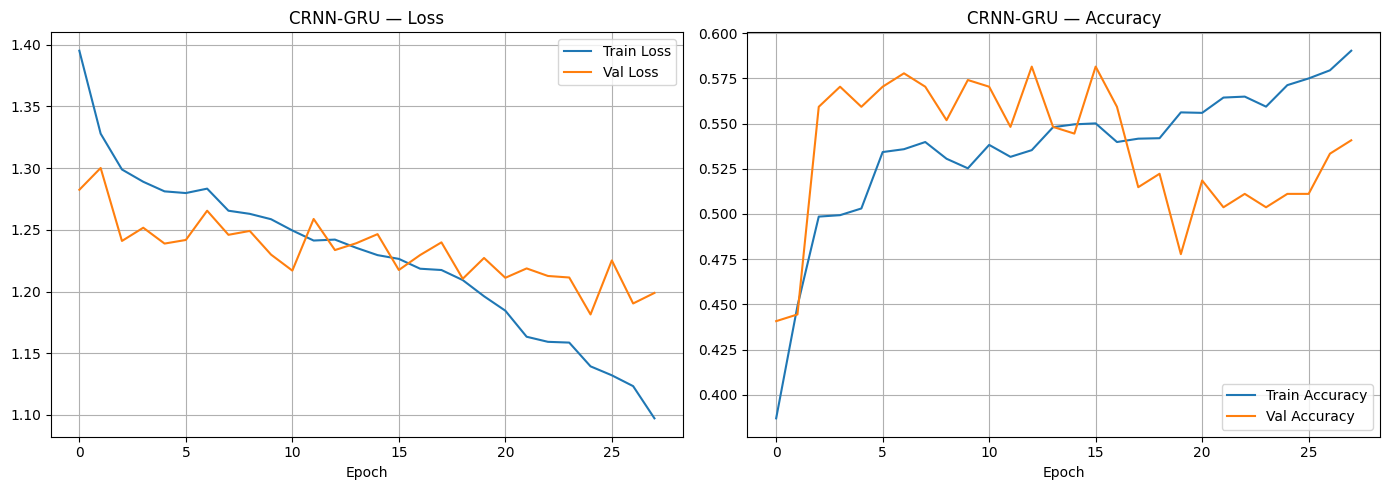

In [45]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Baru dideklarasikan ulang seperti biasa
tf.keras.backend.clear_session()
crnn_model = build_crnn_gru(CRNN_INPUT_SHAPE, NUM_CLASSES)
crnn_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CRNN-GRU...")
history_crnn = crnn_model.fit(
    X_train_crnn, y_train_oh,
    validation_data=(X_val_crnn, y_val_oh),
    epochs=EPOCHS,
    batch_size=16,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks('crnn_gru'),
    verbose=1,
)

print(f"Best val_accuracy CRNN-GRU: {max(history_crnn.history['val_accuracy']):.4f}")
plot_history(history_crnn, 'CRNN-GRU')

## 17. Evaluasi CNN pada Test Set


  Hasil Evaluasi: CNN
  Test Accuracy : 0.5498  (54.98%)
  Weighted F1   : 0.5237
  Macro F1      : 0.4061
  Test Loss     : 1.7059

               precision    recall  f1-score   support

  Angry/Tense       0.00      0.00      0.00        35
 Calm/Relaxed       0.25      0.42      0.31        38
Happy/Excited       0.58      0.87      0.70       102
Sad/Depressed       0.94      0.46      0.62        96

     accuracy                           0.55       271
    macro avg       0.44      0.44      0.41       271
 weighted avg       0.58      0.55      0.52       271



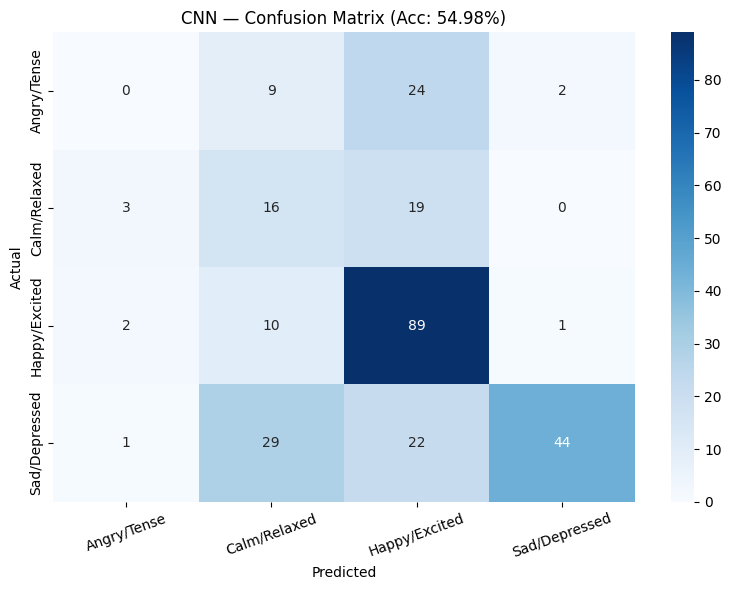

In [46]:
acc_cnn, wf1_cnn, mf1_cnn = evaluate_model(
    cnn_model, X_test_cnn, y_test_oh, y_test_enc, 'CNN'
)

## 18. Evaluasi CRNN-GRU pada Test Set

In [ ]:
acc_crnn, wf1_crnn, mf1_crnn = evaluate_model(
    crnn_model, X_test_crnn, y_test_oh, y_test_enc, 'CRNN-GRU'
)


  Hasil Evaluasi: CRNN-GRU
  Test Accuracy : 0.5793  (57.93%)
  Weighted F1   : 0.5407
  Macro F1      : 0.3993
  Test Loss     : 1.1770

               precision    recall  f1-score   support

  Angry/Tense       0.25      0.03      0.05        35
 Calm/Relaxed       0.14      0.13      0.14        38
Happy/Excited       0.59      0.84      0.70       102
Sad/Depressed       0.76      0.68      0.71        96

     accuracy                           0.58       271
    macro avg       0.43      0.42      0.40       271
 weighted avg       0.54      0.58      0.54       271



## 19. Perbandingan Kedua Model

In [ ]:
results = pd.DataFrame({
    'Model':       ['CNN', 'CRNN-GRU'],
    'Accuracy':    [acc_cnn,  acc_crnn],
    'Weighted F1': [wf1_cnn,  wf1_crnn],
    'Macro F1':    [mf1_cnn,  mf1_crnn],
})

print("=== Perbandingan Model ===")
print(results.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(results))
width = 0.25

ax.bar(x - width, results['Accuracy'],    width, label='Accuracy',    color='steelblue')
ax.bar(x,         results['Weighted F1'], width, label='Weighted F1', color='coral')
ax.bar(x + width, results['Macro F1'],   width, label='Macro F1',    color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('CNN vs CRNN-GRU — Perbandingan Metrik Test Set (DEAM)')
ax.legend()
ax.grid(axis='y', alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

## 20. Simpan Model Terbaik

In [ ]:
best_name  = 'CNN' if acc_cnn >= acc_crnn else 'CRNN-GRU'
best_model = cnn_model if acc_cnn >= acc_crnn else crnn_model
save_path  = f'final_best_{best_name.lower().replace("-", "_")}.keras'

best_model.save(save_path)
print(f"Model terbaik : {best_name}")
print(f"Disimpan ke   : {save_path}")

# Simpan juga label encoder
joblib.dump(le, 'label_encoder.pkl')
print("Label encoder disimpan ke: label_encoder.pkl")